# 1. Business Understanding

## 1.1 Problem Statement
The goal of this project is to develop a machine learning model that predicts the primary contributory cause of traffic crashes in Chicago, enabling stakeholders to identify high-risk conditions and design targeted interventions to improve road safety.

## 1.2 Objectives
- Build a classification model to predict crash causes
- Identify key factors contributing to traffic accidents
- Provide insights that can help reduce accidents

## 1.3 Stakeholders
- Chicago City Planners → prioritize infrastructure improvements (e.g., intersections, lighting)
- Traffic Safety Authorities → design targeted safety campaigns and enforcement strategies
- Policy Makers → implement data-driven regulations to reduce high-risk crash scenarios

## 1.4 Analytical Approach
This problem is framed as a **multi-class classification task**, where the target variable is:

PRIM_CONTRIBUTORY_CAUSE

## 1.5 Success Criteria
The success of the model will be evaluated using:
- Macro F1-score (to handle class imbalance)
- Confusion matrix (to understand misclassifications)
- Interpretability (feature importance analysis)
- Baseline comparison (e.g., majority class or simple model)

## 1.6 Key Challenges
- Imbalanced target classes
- High number of categorical variables
- Data spread across multiple tables (crashes, vehicles, people)
- Risk of data leakage: Some variables may contain information that is only known after the crash occurs (e.g., injury severity, damage estimates). These must be carefully excluded to avoid data leakage and ensure the model reflects real-world prediction scenarios.

# 2. Data Understanding

### Unit of Analysis
The primary unit of analysis will be at the crash level. Therefore, vehicle-level and person-level data will need to be aggregated to align with the crash-level target variable.

## 2.1 Dataset Description
This project uses three datasets provided by the City of Chicago:

- **Crashes Dataset**: Contains information about each traffic crash (e.g., time, location, weather conditions, road conditions).
- **Vehicles Dataset**: Contains details about the vehicles involved in each crash.
- **People Dataset**: Contains information about drivers and passengers involved in each crash.

These datasets are related through a common key: `CRASH_RECORD_ID`.

## 2.2 Objective of This Section
- Load the datasets
- Understand their structure
- Identify key columns
- Perform initial exploration

In [11]:
#import pandas library 
import pandas as pd



# Load datasets
crashes = pd.read_csv("Data/Raw/Traffic_Crashes.csv", index_col=0, low_memory=False)
vehicles = pd.read_csv("Data/Raw/vehicle_data.csv", index_col=0, low_memory=False)
people = pd.read_csv("Data/Raw/passenger_driver.csv", index_col=0, low_memory=False)

# Display shapes
print("Crashes shape:", crashes.shape)
print("Vehicles shape:", vehicles.shape)
print("People shape:", people.shape)

Crashes shape: (251295, 47)
Vehicles shape: (511366, 70)
People shape: (550849, 28)


## 2.3 Data Structure Inspection

Before performing exploratory analysis, we examine the structure of each dataset, including:
- Column names and meanings
- Data types
- Missing values
- Summary statistics

This helps identify data quality issues and informs preprocessing decisions.

In [12]:
print("Crashes Columns:")
print(crashes.columns.tolist())

print("\nVehicles Columns:")
print(vehicles.columns.tolist())

print("\nPeople Columns:")
print(people.columns.tolist())

Crashes Columns:
['CRASH_DATE_EST_I', 'CRASH_DATE', 'POSTED_SPEED_LIMIT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION', 'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE', 'LANE_CNT', 'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE', 'CRASH_TYPE', 'INTERSECTION_RELATED_I', 'NOT_RIGHT_OF_WAY_I', 'HIT_AND_RUN_I', 'DAMAGE', 'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE', 'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION', 'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I', 'NUM_UNITS', 'MOST_SEVERE_INJURY', 'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING', 'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT', 'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE', 'LOCATION']

Vehicles Columns:
['CRASH_RECORD_ID', 'CRASH_DATE', 'UNIT_NO', 'UNIT_TYPE', 'NUM

In [13]:
# crashes data types and missing values
crashes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 251295 entries, 46ea518f2e11a7cb35a3af47503b0e9712237347e0a6d61a3d661fd1f75239b12bba6d5d8af0892a65fd7fb61ca52f51b2031b8562af4e05520089e6cf6710e9 to ce46f735c5c4d216ef355f25b4159dbc97637fbb3431b0d37ef542e1631f8507d053e7c0a0c1788ef64b20ffb43cce956820137ba3acec72e9bce86b19a05a65
Data columns (total 47 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_DATE_EST_I               16190 non-null   object 
 1   CRASH_DATE                     251295 non-null  object 
 2   POSTED_SPEED_LIMIT             251295 non-null  int64  
 3   TRAFFIC_CONTROL_DEVICE         251295 non-null  object 
 4   DEVICE_CONDITION               251295 non-null  object 
 5   WEATHER_CONDITION              251295 non-null  object 
 6   LIGHTING_CONDITION             251295 non-null  object 
 7   FIRST_CRASH_TYPE               251295 non-null  object 
 8   TRAFFICWAY_TYPE               

In [14]:
# vehicles data types and missing values
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511366 entries, 2284891 to 1733631
Data columns (total 70 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CRASH_RECORD_ID           511366 non-null  object 
 1   CRASH_DATE                511366 non-null  object 
 2   UNIT_NO                   511366 non-null  int64  
 3   UNIT_TYPE                 511020 non-null  object 
 4   NUM_PASSENGERS            74864 non-null   float64
 5   VEHICLE_ID                497726 non-null  float64
 6   CMRC_VEH_I                9295 non-null    object 
 7   MAKE                      497726 non-null  object 
 8   MODEL                     497726 non-null  object 
 9   LIC_PLATE_STATE           453010 non-null  object 
 10  VEHICLE_YEAR              427944 non-null  float64
 11  VEHICLE_DEFECT            497726 non-null  object 
 12  VEHICLE_TYPE              497726 non-null  object 
 13  VEHICLE_USE               497726 non-null 

In [15]:
# people data types and missing values
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550849 entries, O2284891 to O1733630
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PERSON_TYPE            550849 non-null  object 
 1   CRASH_RECORD_ID        550849 non-null  object 
 2   VEHICLE_ID             537572 non-null  float64
 3   CRASH_DATE             550849 non-null  object 
 4   SEAT_NO                109115 non-null  float64
 5   CITY                   402011 non-null  object 
 6   STATE                  409448 non-null  object 
 7   ZIPCODE                380516 non-null  object 
 8   SEX                    540181 non-null  object 
 9   AGE                    394788 non-null  float64
 10  DRIVERS_LICENSE_STATE  325326 non-null  object 
 11  DRIVERS_LICENSE_CLASS  255549 non-null  object 
 12  SAFETY_EQUIPMENT       549376 non-null  object 
 13  AIRBAG_DEPLOYED        538046 non-null  object 
 14  EJECTION               543045 no

### Key Observations from Data Structure Inspection

- The crashes dataset contains 251,295 records with 47 features, representing crash-level information such as weather, lighting, road conditions, and crash outcomes.
- The vehicles dataset contains 511,366 records with 70 features, indicating that multiple vehicles can be involved in a single crash.
- The people dataset contains 550,849 records with 28 features, showing that multiple individuals are associated with each crash.

- The datasets are linked using the `CRASH_RECORD_ID`, confirming a relational structure.

- The crashes dataset contains a mix of numerical and categorical variables, with several columns having significant missing values.

- The vehicles dataset has many columns related to commercial vehicles and hazardous materials, most of which have very high missing values and may not be useful for this analysis.

- The people dataset includes detailed driver and passenger information, but also contains several columns with substantial missing data.

- Columns with extremely high missing values (e.g., hazardous material indicators) will be evaluated for removal due to limited informational value.

These observations will guide feature selection, aggregation, and data cleaning in subsequent steps.

## 2.4 Exploratory Data Analysis (EDA)

In this section, we explore the datasets to understand:
- Distribution of the target variable
- Key patterns in crash conditions
- Potential relationships between features and crash causes
- Data quality issues such as missing values and inconsistencies

In [16]:
# Target Variable Distribution
crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10)

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       103475
FAILING TO YIELD RIGHT-OF-WAY              29452
FOLLOWING TOO CLOSELY                      22284
IMPROPER OVERTAKING/PASSING                13651
NOT APPLICABLE                             11930
FAILING TO REDUCE SPEED TO AVOID CRASH     10223
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        10023
IMPROPER TURNING/NO SIGNAL                  8721
IMPROPER LANE USAGE                         8330
IMPROPER BACKING                            7805
Name: count, dtype: int64

In [17]:
#check for imbalance
crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts(normalize=True).head(10)

PRIM_CONTRIBUTORY_CAUSE
UNABLE TO DETERMINE                       0.411767
FAILING TO YIELD RIGHT-OF-WAY             0.117201
FOLLOWING TOO CLOSELY                     0.088677
IMPROPER OVERTAKING/PASSING               0.054323
NOT APPLICABLE                            0.047474
FAILING TO REDUCE SPEED TO AVOID CRASH    0.040681
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.039885
IMPROPER TURNING/NO SIGNAL                0.034704
IMPROPER LANE USAGE                       0.033148
IMPROPER BACKING                          0.031059
Name: proportion, dtype: float64

 The target variable is highly imbalanced, with "UNABLE TO DETERMINE" accounting for over 40% of observations. This category does not represent a meaningful crash cause and will be excluded to improve model interpretability and predictive value.


In [18]:
df = crashes[crashes['PRIM_CONTRIBUTORY_CAUSE'] != 'UNABLE TO DETERMINE']

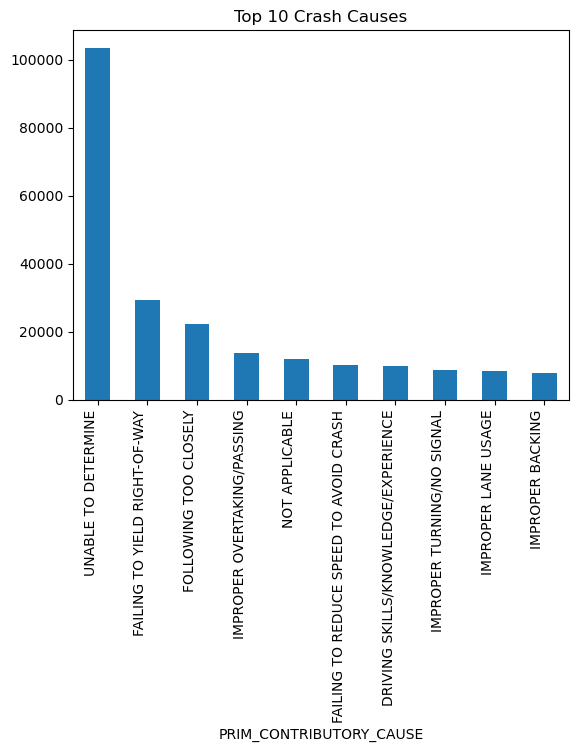

In [19]:
# visualize target variable 
import matplotlib.pyplot as plt

crashes['PRIM_CONTRIBUTORY_CAUSE'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crash Causes")
plt.xticks(rotation=90,ha='right')
plt.show()

In [20]:
#check missing values
missing = crashes.isnull().mean().sort_values(ascending=False)
missing.head(10)

LANE_CNT                  0.999873
WORKERS_PRESENT_I         0.998981
WORK_ZONE_TYPE            0.997191
DOORING_I                 0.996653
WORK_ZONE_I               0.995933
PHOTOS_TAKEN_I            0.981615
STATEMENTS_TAKEN_I        0.969693
NOT_RIGHT_OF_WAY_I        0.960047
CRASH_DATE_EST_I          0.935574
INTERSECTION_RELATED_I    0.767186
dtype: float64

In [21]:
high_missing = missing[missing>0.9].index
crashes = crashes.drop(columns=high_missing)

Columns with more than 90% missing values were removed due to insufficient information content and risk of introducing noise into the model.

In [22]:
#check key feature vs target
pd.crosstab(crashes['WEATHER_CONDITION'], crashes['PRIM_CONTRIBUTORY_CAUSE'])

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,"DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)",DRIVING ON WRONG SIDE/WRONG WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,EQUIPMENT - VEHICLE CONDITION,"EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST",FAILING TO REDUCE SPEED TO AVOID CRASH,FAILING TO YIELD RIGHT-OF-WAY,FOLLOWING TOO CLOSELY,HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),IMPROPER BACKING,IMPROPER LANE USAGE,IMPROPER OVERTAKING/PASSING,IMPROPER TURNING/NO SIGNAL,MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,NOT APPLICABLE,OBSTRUCTED CROSSWALKS,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER",PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNABLE TO DETERMINE,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
WEATHER_CONDITION,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"BLOWING SAND, SOIL, DIRT",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,3,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,7,0,1,1
BLOWING SNOW,0,0,1,0,0,1,7,0,0,0,0,2,5,3,1,9,20,12,0,2,4,5,7,0,8,0,5,0,3,0,0,0,0,0,70,0,2,60
CLEAR,187,15,229,379,245,1774,4011,26,1232,624,115,1276,8033,1084,295,8068,24383,17990,146,6521,6895,11528,7236,2,9236,37,2099,26,1105,202,285,288,52,167,76423,917,1134,488
CLOUDY/OVERCAST,2,0,6,7,11,64,157,0,44,23,5,46,321,69,18,320,1030,738,1,252,292,408,282,0,311,1,93,1,54,7,6,18,0,7,2618,21,64,85
FOG/SMOKE/HAZE,0,0,1,3,0,1,6,0,2,0,0,2,11,1,1,15,36,25,0,7,11,14,12,0,22,0,1,0,1,1,1,2,0,0,92,2,1,15
FREEZING RAIN/DRIZZLE,1,0,0,3,1,9,21,0,6,2,1,5,36,3,3,41,67,60,1,13,24,36,26,0,53,0,10,0,3,0,0,4,0,0,319,4,3,344
OTHER,0,0,0,4,1,7,17,0,2,4,0,1,43,5,0,41,82,39,1,22,15,33,20,0,58,0,9,0,0,2,1,0,0,0,458,3,7,107
RAIN,11,0,14,29,21,191,434,6,88,45,9,113,613,134,28,862,2263,1652,6,397,538,812,630,1,743,4,156,4,83,11,18,27,2,18,6377,85,84,1055
SEVERE CROSS WIND GATE,0,0,0,0,0,0,0,0,0,0,0,0,2,1,0,1,1,2,0,2,0,2,0,0,3,0,0,0,0,0,0,0,0,0,4,0,0,12


In [23]:
#normalize weather conditions
pd.crosstab(
    crashes['WEATHER_CONDITION'], 
    crashes['PRIM_CONTRIBUTORY_CAUSE'],
    normalize='index'
    )

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,"DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)",DRIVING ON WRONG SIDE/WRONG WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,EQUIPMENT - VEHICLE CONDITION,"EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST",FAILING TO REDUCE SPEED TO AVOID CRASH,FAILING TO YIELD RIGHT-OF-WAY,FOLLOWING TOO CLOSELY,HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),IMPROPER BACKING,IMPROPER LANE USAGE,IMPROPER OVERTAKING/PASSING,IMPROPER TURNING/NO SIGNAL,MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,NOT APPLICABLE,OBSTRUCTED CROSSWALKS,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER",PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNABLE TO DETERMINE,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
WEATHER_CONDITION,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
"BLOWING SAND, SOIL, DIRT",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.066667,0.066667,0.200000,0.000000,0.000000,0.000000,0.066667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.466667,0.000000,0.066667,0.066667
BLOWING SNOW,0.000000,0.000000,0.004405,0.000000,0.000000,0.004405,0.030837,0.000000,0.000000,0.000000,0.000000,0.008811,0.022026,0.013216,0.004405,0.039648,0.088106,0.052863,0.000000,0.008811,0.017621,0.022026,0.030837,0.000000,0.035242,0.000000,0.022026,0.000000,0.013216,0.000000,0.000000,0.000000,0.000000,0.000000,0.308370,0.000000,0.008811,0.264317
CLEAR,0.000960,0.000077,0.001176,0.001946,0.001258,0.009109,0.020595,0.000134,0.006326,0.003204,0.000590,0.006552,0.041247,0.005566,0.001515,0.041427,0.125200,0.092373,0.000750,0.033483,0.035404,0.059193,0.037155,0.000010,0.047424,0.000190,0.010778,0.000134,0.005674,0.001037,0.001463,0.001479,0.000267,0.000857,0.392410,0.004709,0.005823,0.002506
CLOUDY/OVERCAST,0.000271,0.000000,0.000813,0.000948,0.001490,0.008670,0.021268,0.000000,0.005960,0.003116,0.000677,0.006231,0.043484,0.009347,0.002438,0.043349,0.139529,0.099973,0.000135,0.034137,0.039556,0.055270,0.038201,0.000000,0.042130,0.000135,0.012598,0.000135,0.007315,0.000948,0.000813,0.002438,0.000000,0.000948,0.354646,0.002845,0.008670,0.011514
FOG/SMOKE/HAZE,0.000000,0.000000,0.003497,0.010490,0.000000,0.003497,0.020979,0.000000,0.006993,0.000000,0.000000,0.006993,0.038462,0.003497,0.003497,0.052448,0.125874,0.087413,0.000000,0.024476,0.038462,0.048951,0.041958,0.000000,0.076923,0.000000,0.003497,0.000000,0.003497,0.003497,0.003497,0.006993,0.000000,0.000000,0.321678,0.006993,0.003497,0.052448
FREEZING RAIN/DRIZZLE,0.000910,0.000000,0.000000,0.002730,0.000910,0.008189,0.019108,0.000000,0.005460,0.001820,0.000910,0.004550,0.032757,0.002730,0.002730,0.037307,0.060965,0.054595,0.000910,0.011829,0.021838,0.032757,0.023658,0.000000,0.048226,0.000000,0.009099,0.000000,0.002730,0.000000,0.000000,0.003640,0.000000,0.000000,0.290264,0.003640,0.002730,0.313012
OTHER,0.000000,0.000000,0.000000,0.004073,0.001018,0.007128,0.017312,0.000000,0.002037,0.004073,0.000000,0.001018,0.043788,0.005092,0.000000,0.041752,0.083503,0.039715,0.001018,0.022403,0.015275,0.033605,0.020367,0.000000,0.059063,0.000000,0.009165,0.000000,0.000000,0.002037,0.001018,0.000000,0.000000,0.000000,0.466395,0.003055,0.007128,0.108961
RAIN,0.000626,0.000000,0.000797,0.001651,0.001196,0.010875,0.024710,0.000342,0.005010,0.002562,0.000512,0.006434,0.034901,0.007629,0.001594,0.049078,0.128843,0.094056,0.000342,0.022603,0.03

In [24]:
pd.crosstab(crashes['LIGHTING_CONDITION'], crashes['PRIM_CONTRIBUTORY_CAUSE'])

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,"DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)",DRIVING ON WRONG SIDE/WRONG WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,EQUIPMENT - VEHICLE CONDITION,"EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST",FAILING TO REDUCE SPEED TO AVOID CRASH,FAILING TO YIELD RIGHT-OF-WAY,FOLLOWING TOO CLOSELY,HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),IMPROPER BACKING,IMPROPER LANE USAGE,IMPROPER OVERTAKING/PASSING,IMPROPER TURNING/NO SIGNAL,MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,NOT APPLICABLE,OBSTRUCTED CROSSWALKS,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER",PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNABLE TO DETERMINE,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
LIGHTING_CONDITION,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DARKNESS,15,1,16,19,3,94,185,1,60,37,12,93,383,57,10,418,961,830,16,325,265,572,342,0,718,4,131,1,67,3,11,21,4,11,4921,82,28,253
"DARKNESS, LIGHTED ROAD",83,2,79,130,70,603,1755,7,394,223,42,578,1825,410,126,3208,5402,3835,80,1418,1746,2652,2022,0,1983,4,902,4,408,39,70,96,24,54,21558,703,185,1233
DAWN,8,0,4,19,8,41,114,0,39,18,1,43,139,19,9,184,473,336,3,97,140,229,157,0,256,0,38,0,40,6,4,6,1,6,1511,30,18,114
DAYLIGHT,99,11,151,260,194,1325,2630,22,887,413,77,734,6871,829,204,5836,21226,16067,65,5488,5419,9447,5785,3,7564,34,1330,28,742,176,237,238,24,122,61865,224,1074,2023
DUSK,5,1,9,14,9,64,135,2,36,22,3,57,229,39,12,292,855,582,4,191,493,369,249,0,326,1,68,1,35,7,4,6,2,7,2283,26,28,111
UNKNOWN,12,0,6,8,12,42,40,1,26,17,1,23,576,23,3,285,535,634,8,286,267,382,166,0,1083,0,63,0,12,0,10,7,3,0,11337,2,7,83


In [25]:
#normalize the lighting conditions
pd.crosstab(
    crashes['LIGHTING_CONDITION'], 
    crashes['PRIM_CONTRIBUTORY_CAUSE'],
    normalize='index'
    )

PRIM_CONTRIBUTORY_CAUSE,ANIMAL,BICYCLE ADVANCING LEGALLY ON RED LIGHT,CELL PHONE USE OTHER THAN TEXTING,DISREGARDING OTHER TRAFFIC SIGNS,DISREGARDING ROAD MARKINGS,DISREGARDING STOP SIGN,DISREGARDING TRAFFIC SIGNALS,DISREGARDING YIELD SIGN,DISTRACTION - FROM INSIDE VEHICLE,DISTRACTION - FROM OUTSIDE VEHICLE,"DISTRACTION - OTHER ELECTRONIC DEVICE (NAVIGATION DEVICE, DVD PLAYER, ETC.)",DRIVING ON WRONG SIDE/WRONG WAY,DRIVING SKILLS/KNOWLEDGE/EXPERIENCE,EQUIPMENT - VEHICLE CONDITION,"EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST",FAILING TO REDUCE SPEED TO AVOID CRASH,FAILING TO YIELD RIGHT-OF-WAY,FOLLOWING TOO CLOSELY,HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE),IMPROPER BACKING,IMPROPER LANE USAGE,IMPROPER OVERTAKING/PASSING,IMPROPER TURNING/NO SIGNAL,MOTORCYCLE ADVANCING LEGALLY ON RED LIGHT,NOT APPLICABLE,OBSTRUCTED CROSSWALKS,"OPERATING VEHICLE IN ERRATIC, RECKLESS, CARELESS, NEGLIGENT OR AGGRESSIVE MANNER",PASSING STOPPED SCHOOL BUS,PHYSICAL CONDITION OF DRIVER,RELATED TO BUS STOP,ROAD CONSTRUCTION/MAINTENANCE,ROAD ENGINEERING/SURFACE/MARKING DEFECTS,TEXTING,TURNING RIGHT ON RED,UNABLE TO DETERMINE,UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED),"VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)",WEATHER
LIGHTING_CONDITION,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
DARKNESS,0.001367,0.000091,0.001459,0.001732,0.000273,0.008569,0.016864,0.000091,0.005469,0.003373,0.001094,0.008478,0.034913,0.005196,0.000912,0.038104,0.087603,0.075661,0.001459,0.029626,0.024157,0.052142,0.031176,0.000000,0.065451,0.000365,0.011942,0.000091,0.006108,0.000273,0.001003,0.001914,0.000365,0.001003,0.448587,0.007475,0.002552,0.023063
"DARKNESS, LIGHTED ROAD",0.001538,0.000037,0.001464,0.002410,0.001297,0.011176,0.032528,0.000130,0.007303,0.004133,0.000778,0.010713,0.033826,0.007599,0.002335,0.059459,0.100124,0.071080,0.001483,0.026282,0.032361,0.049154,0.037477,0.000000,0.036754,0.000074,0.016718,0.000074,0.007562,0.000723,0.001297,0.001779,0.000445,0.001001,0.399570,0.013030,0.003429,0.022853
DAWN,0.001946,0.000000,0.000973,0.004622,0.001946,0.009973,0.027730,0.000000,0.009487,0.004378,0.000243,0.010460,0.033812,0.004622,0.002189,0.044758,0.115057,0.081732,0.000730,0.023595,0.034055,0.055704,0.038190,0.000000,0.062272,0.000000,0.009243,0.000000,0.009730,0.001459,0.000973,0.001459,0.000243,0.001459,0.367550,0.007297,0.004378,0.027730
DAYLIGHT,0.000620,0.000069,0.000945,0.001628,0.001215,0.008296,0.016466,0.000138,0.005553,0.002586,0.000482,0.004595,0.043018,0.005190,0.001277,0.036538,0.132892,0.100592,0.000407,0.034359,0.033927,0.059146,0.036219,0.000019,0.047357,0.000213,0.008327,0.000175,0.004646,0.001102,0.001484,0.001490,0.000150,0.000764,0.387324,0.001402,0.006724,0.012666
DUSK,0.000760,0.000152,0.001368,0.002129,0.001368,0.009731,0.020526,0.000304,0.005474,0.003345,0.000456,0.008667,0.034818,0.005930,0.001825,0.044397,0.129998,0.088490,0.000608,0.029041,0.074958,0.056105,0.037859,0.000000,0.049567,0.000152,0.010339,0.000152,0.005322,0.001064,0.000608,0.000912,0.000304,0.001064,0.347119,0.003953,0.004257,0.016877
UNKNOWN,0.000752,0.000000,0.000376,0.000501,0.000752,0.002632,0.002506,0.000063,0.001629,0.001065,0.000063,0.001441,0.036090,0.001441,0.000188,0.017857,0.033521,0.039724,0.000501,0.017920,0.016729,0.023935,0.010401,0.000000,0.067857,0.000000,0.003947,0.000000,0.000752,0.000000,0.000627,0.000439,0.000188,0.000000,0.710338,0.000125,0.000439,0.005201


### Identifying leaking features

In [26]:
crashes.info()

<class 'pandas.core.frame.DataFrame'>
Index: 251295 entries, 46ea518f2e11a7cb35a3af47503b0e9712237347e0a6d61a3d661fd1f75239b12bba6d5d8af0892a65fd7fb61ca52f51b2031b8562af4e05520089e6cf6710e9 to ce46f735c5c4d216ef355f25b4159dbc97637fbb3431b0d37ef542e1631f8507d053e7c0a0c1788ef64b20ffb43cce956820137ba3acec72e9bce86b19a05a65
Data columns (total 38 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CRASH_DATE                     251295 non-null  object 
 1   POSTED_SPEED_LIMIT             251295 non-null  int64  
 2   TRAFFIC_CONTROL_DEVICE         251295 non-null  object 
 3   DEVICE_CONDITION               251295 non-null  object 
 4   WEATHER_CONDITION              251295 non-null  object 
 5   LIGHTING_CONDITION             251295 non-null  object 
 6   FIRST_CRASH_TYPE               251295 non-null  object 
 7   TRAFFICWAY_TYPE                251295 non-null  object 
 8   ALIGNMENT                     

In [27]:
people.info()

<class 'pandas.core.frame.DataFrame'>
Index: 550849 entries, O2284891 to O1733630
Data columns (total 28 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PERSON_TYPE            550849 non-null  object 
 1   CRASH_RECORD_ID        550849 non-null  object 
 2   VEHICLE_ID             537572 non-null  float64
 3   CRASH_DATE             550849 non-null  object 
 4   SEAT_NO                109115 non-null  float64
 5   CITY                   402011 non-null  object 
 6   STATE                  409448 non-null  object 
 7   ZIPCODE                380516 non-null  object 
 8   SEX                    540181 non-null  object 
 9   AGE                    394788 non-null  float64
 10  DRIVERS_LICENSE_STATE  325326 non-null  object 
 11  DRIVERS_LICENSE_CLASS  255549 non-null  object 
 12  SAFETY_EQUIPMENT       549376 non-null  object 
 13  AIRBAG_DEPLOYED        538046 non-null  object 
 14  EJECTION               543045 no

In [28]:
vehicles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511366 entries, 2284891 to 1733631
Data columns (total 70 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CRASH_RECORD_ID           511366 non-null  object 
 1   CRASH_DATE                511366 non-null  object 
 2   UNIT_NO                   511366 non-null  int64  
 3   UNIT_TYPE                 511020 non-null  object 
 4   NUM_PASSENGERS            74864 non-null   float64
 5   VEHICLE_ID                497726 non-null  float64
 6   CMRC_VEH_I                9295 non-null    object 
 7   MAKE                      497726 non-null  object 
 8   MODEL                     497726 non-null  object 
 9   LIC_PLATE_STATE           453010 non-null  object 
 10  VEHICLE_YEAR              427944 non-null  float64
 11  VEHICLE_DEFECT            497726 non-null  object 
 12  VEHICLE_TYPE              497726 non-null  object 
 13  VEHICLE_USE               497726 non-null 

- Target variable - We drop unable to determinne and not applicable. They are not useful

### Features strongly affecting the target variable


In [29]:
# Features from the 'crashes' table
crash_cols = [
    'CRASH_RECORD_ID', 'PRIM_CONTRIBUTORY_CAUSE', 'WEATHER_CONDITION', 
    'LIGHTING_CONDITION', 'ROADWAY_SURFACE_COND', 'TRAFFICWAY_TYPE', 
    'ALIGNMENT', 'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 
    'CRASH_HOUR', 'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'POSTED_SPEED_LIMIT'
]

# Features from the 'vehicles' table
vehicle_cols = ['CRASH_RECORD_ID', 'MANEUVER', 'VEHICLE_TYPE']

# Features from the 'people' table
people_cols = ['CRASH_RECORD_ID', 'DRIVER_ACTION', 'DRIVER_VISION', 
               'PHYSICAL_CONDITION', 'AGE', 'SEX']

In [30]:
crashes = crashes.reset_index()

print(crashes.columns)

Index(['CRASH_RECORD_ID', 'CRASH_DATE', 'POSTED_SPEED_LIMIT',
       'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'WEATHER_CONDITION',
       'LIGHTING_CONDITION', 'FIRST_CRASH_TYPE', 'TRAFFICWAY_TYPE',
       'ALIGNMENT', 'ROADWAY_SURFACE_COND', 'ROAD_DEFECT', 'REPORT_TYPE',
       'CRASH_TYPE', 'INTERSECTION_RELATED_I', 'HIT_AND_RUN_I', 'DAMAGE',
       'DATE_POLICE_NOTIFIED', 'PRIM_CONTRIBUTORY_CAUSE',
       'SEC_CONTRIBUTORY_CAUSE', 'STREET_NO', 'STREET_DIRECTION',
       'STREET_NAME', 'BEAT_OF_OCCURRENCE', 'NUM_UNITS', 'MOST_SEVERE_INJURY',
       'INJURIES_TOTAL', 'INJURIES_FATAL', 'INJURIES_INCAPACITATING',
       'INJURIES_NON_INCAPACITATING', 'INJURIES_REPORTED_NOT_EVIDENT',
       'INJURIES_NO_INDICATION', 'INJURIES_UNKNOWN', 'CRASH_HOUR',
       'CRASH_DAY_OF_WEEK', 'CRASH_MONTH', 'LATITUDE', 'LONGITUDE',
       'LOCATION'],
      dtype='object')


In [31]:
df_model = crashes[crash_cols].merge(vehicles[vehicle_cols], on='CRASH_RECORD_ID', how='left')

df_model = df_model.merge(people[people_cols], on='CRASH_RECORD_ID', how='left')


In [32]:
tables = {"crashes": crashes, "vehicles": vehicles, "people": people}

for name, table in tables.items():
    if 'CRASH_RECORD_ID' in table.columns:
        print(f"✅ {name} has 'CRASH_RECORD_ID'")
    else:
        print(f"{name} is MISSING 'CRASH_RECORD_ID'!")
        print(f"Available columns in {name}: {table.columns.tolist()[:5]}...")

✅ crashes has 'CRASH_RECORD_ID'
✅ vehicles has 'CRASH_RECORD_ID'
✅ people has 'CRASH_RECORD_ID'


In [33]:

raw_columns = pd.read_csv('Data/Raw/Traffic_Crashes.csv', nrows=0).columns

dropped_cols = [col for col in raw_columns if col not in crashes.columns]

print(f"The dropped {len(dropped_cols)} columns:")
print(dropped_cols)

The dropped 9 columns:
['CRASH_DATE_EST_I', 'LANE_CNT', 'NOT_RIGHT_OF_WAY_I', 'PHOTOS_TAKEN_I', 'STATEMENTS_TAKEN_I', 'DOORING_I', 'WORK_ZONE_I', 'WORK_ZONE_TYPE', 'WORKERS_PRESENT_I']


### ENVIRONMENT

1. - Weather condition - affects  visibility


2.  Lighting condition -visibility issues (night and dark)

### ROAD FEATURES

3. Road surface cond- are the roads slippery are they snowy. Due to the conditions of the road surface it is easier to loose control

4. Trafficway type - there are risks in intersections as well as the highway. In the highway incase the vehicle fails or the driver looses his attention ther is a high likelyhood of accidents as well as intersections incase a driver fails to use his side mirrors and indicate on time its also a high likelyhood

5. Alignment - curves increase accident likelihood especially when the curves and meandors are not signaled correctly(traffic signs )

### TRAFFIC FEATURES

6. Traffic control device - signal  and stop signs affect driver behaviour

7. Device codition - broken signals 

### VEHICLE FEATURES

9. Maneuver - what was the driver doing

10. Vehicle type - trucks vs cars are different on the road

11. Vehicle defect - mechanical issues

### PEOPLE

12. Driver Action - speeding , failure to give way

13. Driver vision - obstructions

14. Physical condition - driver is fatigued or ill

15. Age - there is a risk for the young vs old

16. Sex - behaviour differences

### TIME FEATURES

17. Crash hour - night vs day patterns

18. Crash day of week - patterns during weekdays and weekends

19. Crash month - seasonal patterns

### NUMERIC FEATURES

20. Posted speed limit- severity

### FEATURES TO IGNORE

- Injuries- it describes the outcome of the crash i.e. number of injuries and occur after the event
- Injury classification- its classified after the severity of harm sustained after the crash
- EMS/ Hospital- this is emergency response after the crash
- Damage - the level of damage is assessed after the crash
- Report type - done later by the police
- Towed - its a consequence of the crash not the crash cause it just tells the model how severe the crash was and the severity is not a cause
- Street name- has way too many value counts(high cardinality)
- make - high cardinality
- model- high cardinality
- cell phone use -few values
- hazmat- high imbalance, does not represent the crash populatiin
- trailer- its only for specific vehicle types


In [34]:
crashes['STREET_NAME'].value_counts()

STREET_NAME
WESTERN AVE         7039
PULASKI RD          5961
CICERO AVE          5673
ASHLAND AVE         5422
KEDZIE AVE          4613
                    ... 
NORTHCOTT AVE          1
SENOUR AVE             1
LIANO AVE              1
EDWARD BARRON DR       1
PARKVIEW TER           1
Name: count, Length: 1463, dtype: int64

In [35]:
selected_features = [
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "ROADWAY_SURFACE_COND",
    "TRAFFICWAY_TYPE",
    "ALIGNMENT",
    "TRAFFIC_CONTROL_DEVICE",
    "DEVICE_CONDITION",
    "MANEUVER",
    "VEHICLE_TYPE",
    "DRIVER_ACTION",
    "DRIVER_VISION",
    "PHYSICAL_CONDITION",
    "AGE",
    "SEX",
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "POSTED_SPEED_LIMIT"
]

We are telling python that it should only pick the 10 largest contributors  of weather conditions. We have also normalized the weather data and also avoid large data that will lead us to a trap

In [36]:
def plot_category_heatmap(df, feature, target, top_n=10):
    top_targets = df[target].value_counts().nlargest(top_n).index
    subset = df[df[target].isin(top_targets)]
    
    
    ct = pd.crosstab(subset[feature], subset[target], normalize='index')
    
    plt.figure(figsize=(14, 7))
    sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".2f")
    plt.title(f"Impact of {feature} on Top {top_n} Crash causes")
    plt.show()

plot_category_heatmap(df_model, 'WEATHER_CONDITION', 'PRIM_CONTRIBUTORY_CAUSE')

NameError: name 'sns' is not defined

<Figure size 1400x700 with 0 Axes>

This a visualization of the numerical columns, we have used sharley=True to combine all 3 plots to use the same y-axis.
It shows how age,crash hour and speed affect our target variable

C:\Users\PC\AppData\Local\Temp\ipykernel_16080\34207615.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_plot, x=col, y='PRIM_CONTRIBUTORY_CAUSE', palette='flare')
C:\Users\PC\AppData\Local\Temp\ipykernel_16080\34207615.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_plot, x=col, y='PRIM_CONTRIBUTORY_CAUSE', palette='flare')
C:\Users\PC\AppData\Local\Temp\ipykernel_16080\34207615.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[i], data=df_plot, x=col, y='PRIM_CONTRIBUTORY_CAUSE', 

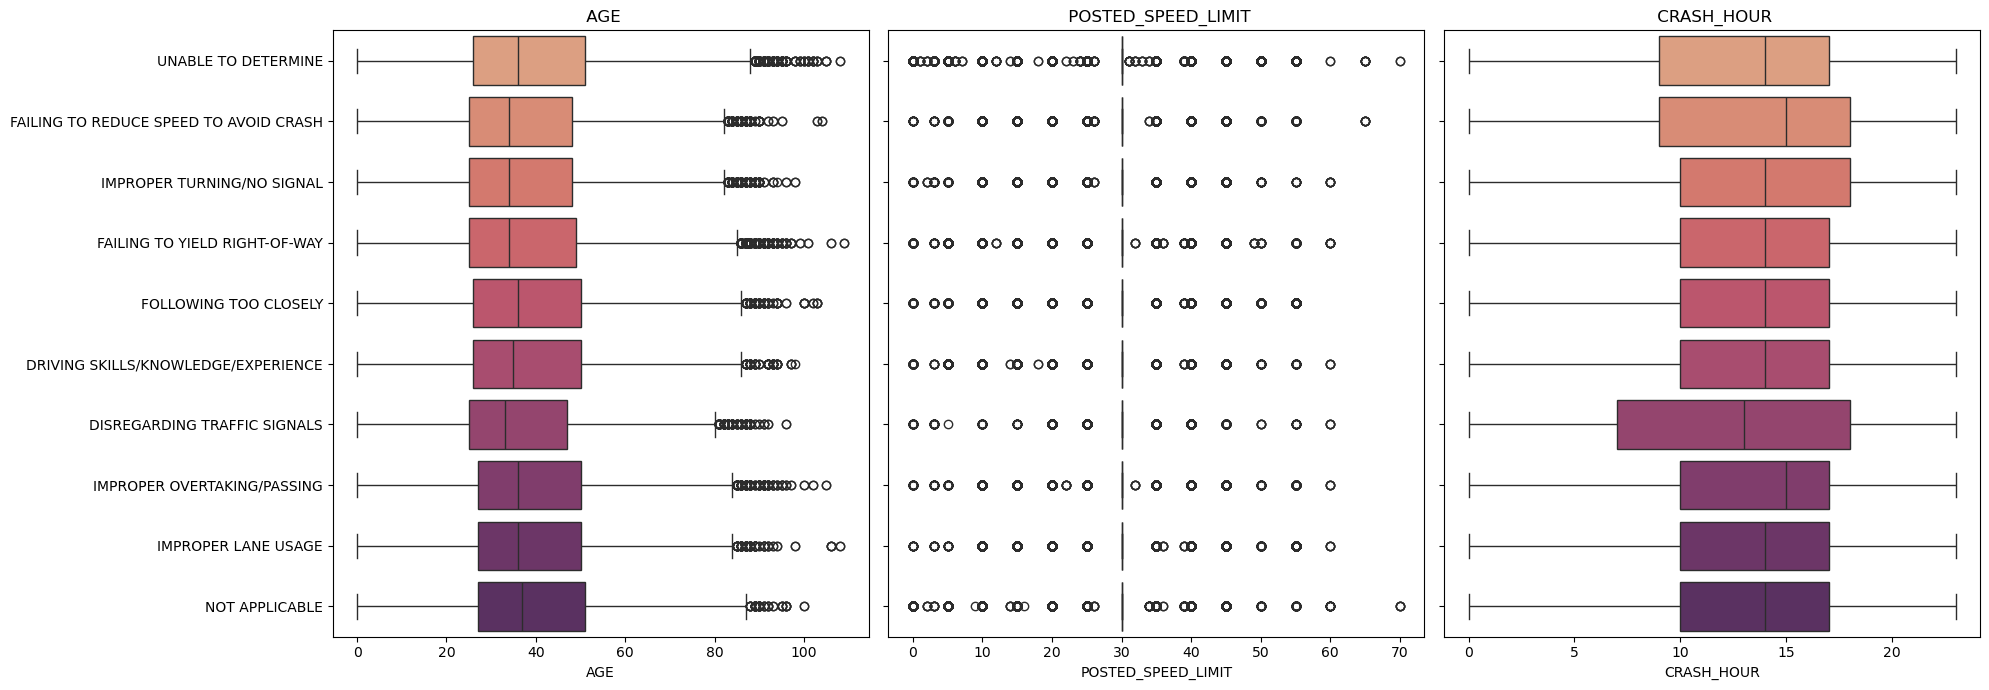

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

top_10 = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts().nlargest(10).index
df_plot = df_model[df_model['PRIM_CONTRIBUTORY_CAUSE'].isin(top_10)]


fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)


for i, col in enumerate(["AGE", "POSTED_SPEED_LIMIT", "CRASH_HOUR"]):
    sns.boxplot(ax=axes[i], data=df_plot, x=col, y='PRIM_CONTRIBUTORY_CAUSE', palette='flare')
    axes[i].set_title(f" {col}")
    axes[i].set_ylabel("") 

plt.tight_layout()
plt.show()

# **Target Variable Strategy**
- What Exactly Are We Predicting?

We are predicting:

The cause of the crash, not the outcome.

This means:

- We focus on driver behavior, environment, road, and vehicle conditions
- We exclude consequences of the crash.

In [38]:
# Choice of Target Variable
target = "PRIM_CONTRIBUTORY_CAUSE"

In [39]:
# Cleaning Target Variable
# Remove non-informative target classes
df_model = df_model[
    ~df_model['PRIM_CONTRIBUTORY_CAUSE'].isin(
        ['UNABLE TO DETERMINE', 'NOT APPLICABLE']
    )
]

#### Checking Target Distribution
- This answers the question of " Is it learnable?Hence we determine the distribution of thr Target Variable


In [40]:
# Check class distribution
target_counts = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts()

print(target_counts.head(10))

PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY             155853
FOLLOWING TOO CLOSELY                     118084
IMPROPER OVERTAKING/PASSING                66687
FAILING TO REDUCE SPEED TO AVOID CRASH     53981
IMPROPER TURNING/NO SIGNAL                 43897
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        40513
IMPROPER LANE USAGE                        39294
DISREGARDING TRAFFIC SIGNALS               30877
IMPROPER BACKING                           30450
WEATHER                                    15439
Name: count, dtype: int64


In [41]:
# Normalize distribution
target_distribution = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts(normalize=True)

print(target_distribution.head(10))

PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY             0.230858
FOLLOWING TOO CLOSELY                     0.174913
IMPROPER OVERTAKING/PASSING               0.098781
FAILING TO REDUCE SPEED TO AVOID CRASH    0.079960
IMPROPER TURNING/NO SIGNAL                0.065023
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.060010
IMPROPER LANE USAGE                       0.058205
DISREGARDING TRAFFIC SIGNALS              0.045737
IMPROPER BACKING                          0.045104
WEATHER                                   0.022869
Name: proportion, dtype: float64


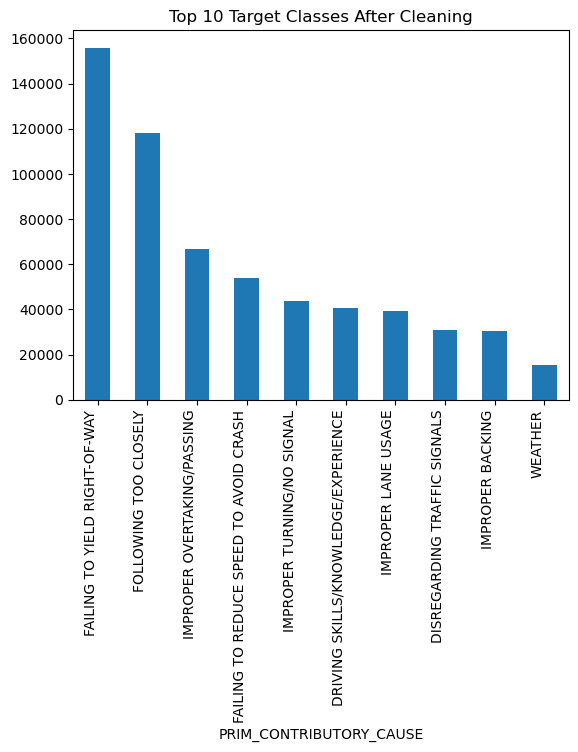

In [42]:
#Visualise Target Imbalance
import matplotlib.pyplot as plt

target_counts.head(10).plot(kind='bar')
plt.title("Top 10 Target Classes After Cleaning")
plt.xticks(rotation=90, ha='right')
plt.show()


Now, let us answer "Is this Target Learnable?" 
we do this by focusing on the Top N most frequent classes. This will help us because:
 - Improves Model Performance
 - Make our evaluation meaningful
 - Reduces Noise

In [43]:
# Select top 10 most frequent causes
top_n = 10

top_classes = df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts().nlargest(top_n).index

df_model = df_model[df_model['PRIM_CONTRIBUTORY_CAUSE'].isin(top_classes)]

print(f"Remaining classes: {len(top_classes)}")
print(top_classes)

Remaining classes: 10
Index(['FAILING TO YIELD RIGHT-OF-WAY', 'FOLLOWING TOO CLOSELY',
       'IMPROPER OVERTAKING/PASSING', 'FAILING TO REDUCE SPEED TO AVOID CRASH',
       'IMPROPER TURNING/NO SIGNAL', 'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE',
       'IMPROPER LANE USAGE', 'DISREGARDING TRAFFIC SIGNALS',
       'IMPROPER BACKING', 'WEATHER'],
      dtype='object', name='PRIM_CONTRIBUTORY_CAUSE')


In [44]:
# Final Target Distribution
df_model['PRIM_CONTRIBUTORY_CAUSE'].value_counts()

PRIM_CONTRIBUTORY_CAUSE
FAILING TO YIELD RIGHT-OF-WAY             155853
FOLLOWING TOO CLOSELY                     118084
IMPROPER OVERTAKING/PASSING                66687
FAILING TO REDUCE SPEED TO AVOID CRASH     53981
IMPROPER TURNING/NO SIGNAL                 43897
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        40513
IMPROPER LANE USAGE                        39294
DISREGARDING TRAFFIC SIGNALS               30877
IMPROPER BACKING                           30450
WEATHER                                    15439
Name: count, dtype: int64

### Data Cleaning and Preparation

In [45]:
df_model.shape

(595075, 20)

In [46]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 595075 entries, 2 to 1148748
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CRASH_RECORD_ID          595075 non-null  object 
 1   PRIM_CONTRIBUTORY_CAUSE  595075 non-null  object 
 2   WEATHER_CONDITION        595075 non-null  object 
 3   LIGHTING_CONDITION       595075 non-null  object 
 4   ROADWAY_SURFACE_COND     595075 non-null  object 
 5   TRAFFICWAY_TYPE          595075 non-null  object 
 6   ALIGNMENT                595075 non-null  object 
 7   TRAFFIC_CONTROL_DEVICE   595075 non-null  object 
 8   DEVICE_CONDITION         595075 non-null  object 
 9   CRASH_HOUR               595075 non-null  int64  
 10  CRASH_DAY_OF_WEEK        595075 non-null  int64  
 11  CRASH_MONTH              595075 non-null  int64  
 12  POSTED_SPEED_LIMIT       595075 non-null  int64  
 13  MANEUVER                 580838 non-null  object 
 14  VEHICLE_

In [47]:
df_model.isnull().sum().sort_values(ascending=False).head(10)

AGE                        141750
DRIVER_VISION              126876
DRIVER_ACTION              126667
PHYSICAL_CONDITION         126375
VEHICLE_TYPE                14237
MANEUVER                    14237
SEX                         11766
PRIM_CONTRIBUTORY_CAUSE         0
POSTED_SPEED_LIMIT              0
CRASH_MONTH                     0
dtype: int64

In [48]:
df_model[['AGE','DRIVER_VISION','DRIVER_ACTION',
          'PHYSICAL_CONDITION','VEHICLE_TYPE',
          'MANEUVER','SEX']].isnull().mean().sort_values(ascending=False).head(10)

AGE                   0.238205
DRIVER_VISION         0.213210
DRIVER_ACTION         0.212859
PHYSICAL_CONDITION    0.212368
VEHICLE_TYPE          0.023925
MANEUVER              0.023925
SEX                   0.019772
dtype: float64

In [49]:
df_model['AGE'] = df_model['AGE'].fillna(df_model['AGE'].median())

In [50]:
cat_cols = [
    'DRIVER_VISION',
    'DRIVER_ACTION',
    'PHYSICAL_CONDITION',
    'VEHICLE_TYPE',
    'MANEUVER',
    'SEX'
]

for col in cat_cols:
    df_model[col] = df_model[col].fillna('Unknown')

In [51]:
df_model.isnull().sum().sort_values(ascending=False).head(10)

CRASH_RECORD_ID            0
PRIM_CONTRIBUTORY_CAUSE    0
AGE                        0
PHYSICAL_CONDITION         0
DRIVER_VISION              0
DRIVER_ACTION              0
VEHICLE_TYPE               0
MANEUVER                   0
POSTED_SPEED_LIMIT         0
CRASH_MONTH                0
dtype: int64

In [52]:
df_model.shape

(595075, 20)

### Train-Test Split

In [53]:
from sklearn.model_selection import train_test_split

X = df_model.drop('PRIM_CONTRIBUTORY_CAUSE', axis=1)
y = df_model['PRIM_CONTRIBUTORY_CAUSE']

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)  


### Encoding Categorical variables

#### Identifying categorical variables

In [54]:
cat_cols = X_train.select_dtypes(include=['object']).columns
cat_cols

Index(['CRASH_RECORD_ID', 'WEATHER_CONDITION', 'LIGHTING_CONDITION',
       'ROADWAY_SURFACE_COND', 'TRAFFICWAY_TYPE', 'ALIGNMENT',
       'TRAFFIC_CONTROL_DEVICE', 'DEVICE_CONDITION', 'MANEUVER',
       'VEHICLE_TYPE', 'DRIVER_ACTION', 'DRIVER_VISION', 'PHYSICAL_CONDITION',
       'SEX'],
      dtype='object')

In [55]:
X_train.nunique().sort_values(ascending=False).head(20)

CRASH_RECORD_ID           118103
AGE                          108
POSTED_SPEED_LIMIT            28
MANEUVER                      26
CRASH_HOUR                    24
VEHICLE_TYPE                  22
DRIVER_ACTION                 21
TRAFFICWAY_TYPE               20
TRAFFIC_CONTROL_DEVICE        18
DRIVER_VISION                 15
PHYSICAL_CONDITION            13
WEATHER_CONDITION             12
CRASH_MONTH                   12
DEVICE_CONDITION               8
CRASH_DAY_OF_WEEK              7
ROADWAY_SURFACE_COND           7
ALIGNMENT                      6
LIGHTING_CONDITION             6
SEX                            4
dtype: int64

##### Removing high-cardinality columns

In [56]:
X_train = X_train.drop(columns=['CRASH_RECORD_ID'], errors='ignore')
X_test = X_test.drop(columns=['CRASH_RECORD_ID'], errors='ignore')

In [57]:
'CRASH_RECORD_ID' in X_train.columns

False

##### Applying One-Hot-Encoding on Train and Test set

In [58]:
cat_cols = X_train.select_dtypes(include='object').columns

X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

In [59]:
X_train_encoded.shape, X_test_encoded.shape

((476060, 170), (119015, 170))

##  Baseline Model

###  Why a Baseline Model?

We want to use this to establish a performance benchmark that more complex models will be compared against.

It helps us answer:
- Is our problem learnable?
- Are our features meaningful?
- Do advanced models actually improve performance?

For this project, we will use Logistic Regression as our baseline models.

#### Why Logistic Regression?

Logistic Regression is chosen as the baseline model because:

- It is simple and fast to train
- It performs well on high-dimensional data (after one-hot encoding)
- It provides a strong baseline for classification tasks
- It is easy to interpret
- It handles multi-class classification effectively using strategies like one-vs-rest

Additionally, we apply class balancing to handle class imbalance in the dataset.

In [60]:
# Train Baseline Model
from sklearn.linear_model import LogisticRegression

# Initialize model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1
)

# Train model
log_model.fit(X_train_encoded, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [61]:
# Making Predictions
y_pred = log_model.predict(X_test_encoded)

In [63]:
#Evaluate Model
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                                        precision    recall  f1-score   support

          DISREGARDING TRAFFIC SIGNALS       0.31      0.79      0.44      6175
   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.25      0.28      0.27      8103
FAILING TO REDUCE SPEED TO AVOID CRASH       0.27      0.20      0.23     10796
         FAILING TO YIELD RIGHT-OF-WAY       0.73      0.46      0.56     31171
                 FOLLOWING TOO CLOSELY       0.57      0.53      0.55     23617
                      IMPROPER BACKING       0.65      0.76      0.70      6090
                   IMPROPER LANE USAGE       0.36      0.37      0.37      7859
           IMPROPER OVERTAKING/PASSING       0.68      0.40      0.51     13337
            IMPROPER TURNING/NO SIGNAL       0.43      0.55      0.48      8779
                               WEATHER       0.27      0.85      0.41      3088

                              accuracy                           0.48    119015
               

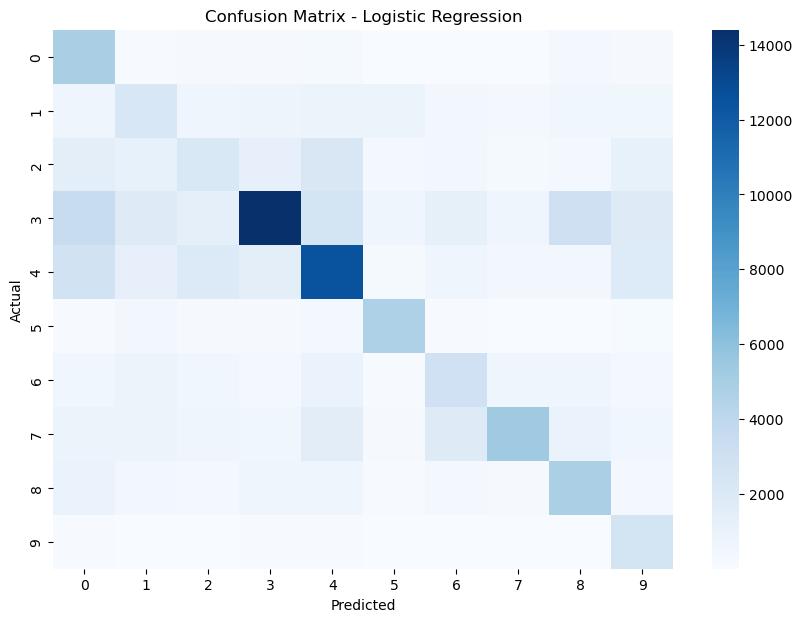

In [ ]:
# Confusion Matrix for the Logistic Regression
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Baseline Model Interpretation

The Logistic Regression model provides a baseline performance for predicting crash causes.

Key observations:
- The model performs better on majority classes compared to minority classes
- Class imbalance affects prediction quality for less frequent crash causes
- Some classes may be confused with similar driver behavior patterns

### FEATURE PERFORMANCE AND VISUALIZATION FOR FEATURES STRONGLY AFFECTING THE TARGET VARIABLE AND FEATURES THAT ARE NOT HELPFUL

In [ ]:
from scipy.stats import stats, chi2_contingency
import numpy as np
num_cols= ["AGE", "CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH", "POSTED_SPEED_LIMIT"]\

results = []


In [ ]:
 # Calculate ANOVA for Numerical Features
for col in num_cols:
    # Clean NaNs and get groups
    df_clean = df_model.dropna(subset=[col, 'PRIM_CONTRIBUTORY_CAUSE'])
    groups = [group[col].values for name, group in df_clean.groupby('PRIM_CONTRIBUTORY_CAUSE') if len(group) > 1]
    
    if len(groups) > 1:
        _, p_val = stats.f_oneway(*groups)
        results.append({'Feature': col, 'p_value': p_val, 'Type': 'Numerical (ANOVA)'})

C:\Users\PC\AppData\Local\Temp\ipykernel_7320\322610569.py:8: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  _, p_val = stats.f_oneway(*groups)
C:\Users\PC\AppData\Local\Temp\ipykernel_7320\322610569.py:8: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  _, p_val = stats.f_oneway(*groups)
C:\Users\PC\AppData\Local\Temp\ipykernel_7320\322610569.py:8: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  _, p_val = stats.f_oneway(*groups)
C:\Users\PC\AppData\Local\Temp\ipykernel_7320\322610569.py:8: DeprecationWarning: Please import `f_oneway` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in Sc

In [ ]:
#  Calculate Chi-Square for Categorical Features
for col in cat_cols:
    contingency_table = pd.crosstab(df_model[col], df_model['PRIM_CONTRIBUTORY_CAUSE'])
    _, p_val, _, _ = chi2_contingency(contingency_table)
    results.append({'Feature': col, 'p_value': p_val, 'Type': 'Categorical (Chi-Square)'})

In [ ]:
# Transform into a Plotting DataFrame
stat_df = pd.DataFrame(results)
# Use -log10(p) for the "Significance Score". We clip it to 100 to prevent infinity.
stat_df['Significance_Score'] = -np.log10(stat_df['p_value'].replace(0, 1e-100))
stat_df = stat_df.sort_values(by='Significance_Score', ascending=False)

The visualization below shows the strongest features

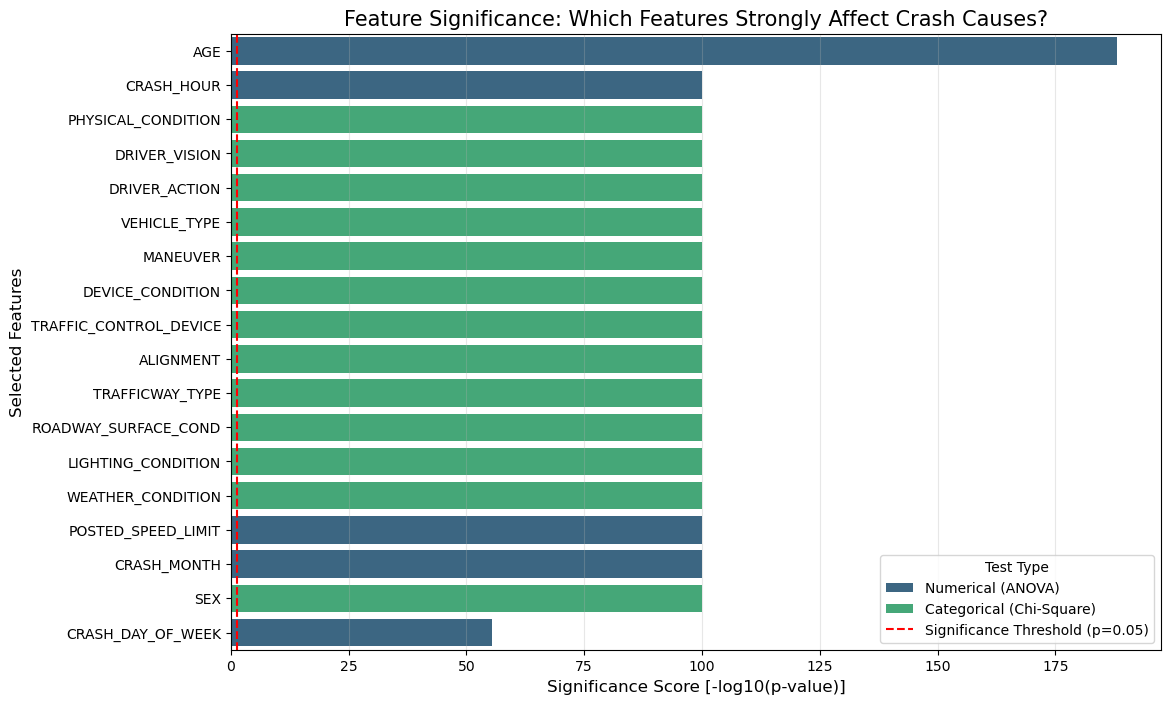

In [ ]:
#  The Visualization
plt.figure(figsize=(12, 8))
sns.barplot(data=stat_df, x='Significance_Score', y='Feature', hue='Type', palette='viridis')

# Add the significance threshold line (p=0.05)
plt.axvline(x=-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold (p=0.05)')

plt.title("Feature Significance: Which Features Strongly Affect Crash Causes?", fontsize=15)
plt.xlabel("Significance Score [-log10(p-value)]", fontsize=12)
plt.ylabel("Selected Features", fontsize=12)
plt.legend(title="Test Type", loc='lower right')
plt.grid(axis='x', alpha=0.3)
plt.show()

This features are not helpful to our target variable

In [ ]:
ignore_features = [
    # Leakage (post-crash outcomes)
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "INJURIES_INCAPACITATING",
    "INJURIES_NON_INCAPACITATING",
    "INJURIES_REPORTED_NOT_EVIDENT",
    "INJURIES_NO_INDICATION",
    "INJURIES_UNKNOWN",
    "INJURY_CLASSIFICATION",
    "HOSPITAL",
    "EMS_AGENCY",
    "EMS_RUN_NO",

    # Post-event / severity indicators
    "DAMAGE",
    "REPORT_TYPE",
    "DATE_POLICE_NOTIFIED",
    "TOWED_I",
    "TOWED_BY",
    "TOWED_TO",
    "FIRE_I",

    # Target leakage
    "SEC_CONTRIBUTORY_CAUSE",

    # High cardinality (overfitting risk)
    "STREET_NAME",
    "STREET_NO",
    "LOCATION",
    "MAKE",
    "MODEL",
    "CARRIER_NAME",
    "ZIPCODE",

    # Sparse / weak features
    "CELL_PHONE_USE",
    "PEDPEDAL_ACTION",
    "PEDPEDAL_VISIBILITY",
    "PEDPEDAL_LOCATION",
    "EXCEED_SPEED_LIMIT_I",

    # Rare / domain-specific
    "HAZMAT_PLACARDS_I",
    "HAZMAT_NAME",
    "HAZMAT_PRESENT_I",
    "HAZMAT_REPORT_I",
    "HAZMAT_REPORT_NO",
    "HAZMAT_VIO_CAUSE_CRASH_I",
    "HAZMAT_OUT_OF_SERVICE_I",
    "HAZMAT_CLASS",
    "UN_NO",

    "TRAILER1_WIDTH",
    "TRAILER2_WIDTH",
    "TRAILER1_LENGTH",
    "TRAILER2_LENGTH",
    "TOTAL_VEHICLE_LENGTH",
    "AXLE_CNT",
    "VEHICLE_CONFIG",
    "CARGO_BODY_TYPE",
    "LOAD_TYPE",

    # IDs (not useful for modeling)
    "CRASH_RECORD_ID",
    "VEHICLE_ID",
    "UNIT_NO"
]

This code visualizes and validates that the feature variables we are ignoring are not helpful

C:\Users\PC\AppData\Local\Temp\ipykernel_7320\408989194.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=top_missing, x='Missing_Pct', y='Feature', palette='Reds_r')
C:\Users\PC\AppData\Local\Temp\ipykernel_7320\408989194.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=top_card, x='Cardinality', y='Feature', palette='Blues_r')
C:\Users\PC\AppData\Local\Temp\ipykernel_7320\408989194.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=top_leak, x='Leakage_Score', y='Feature', palette

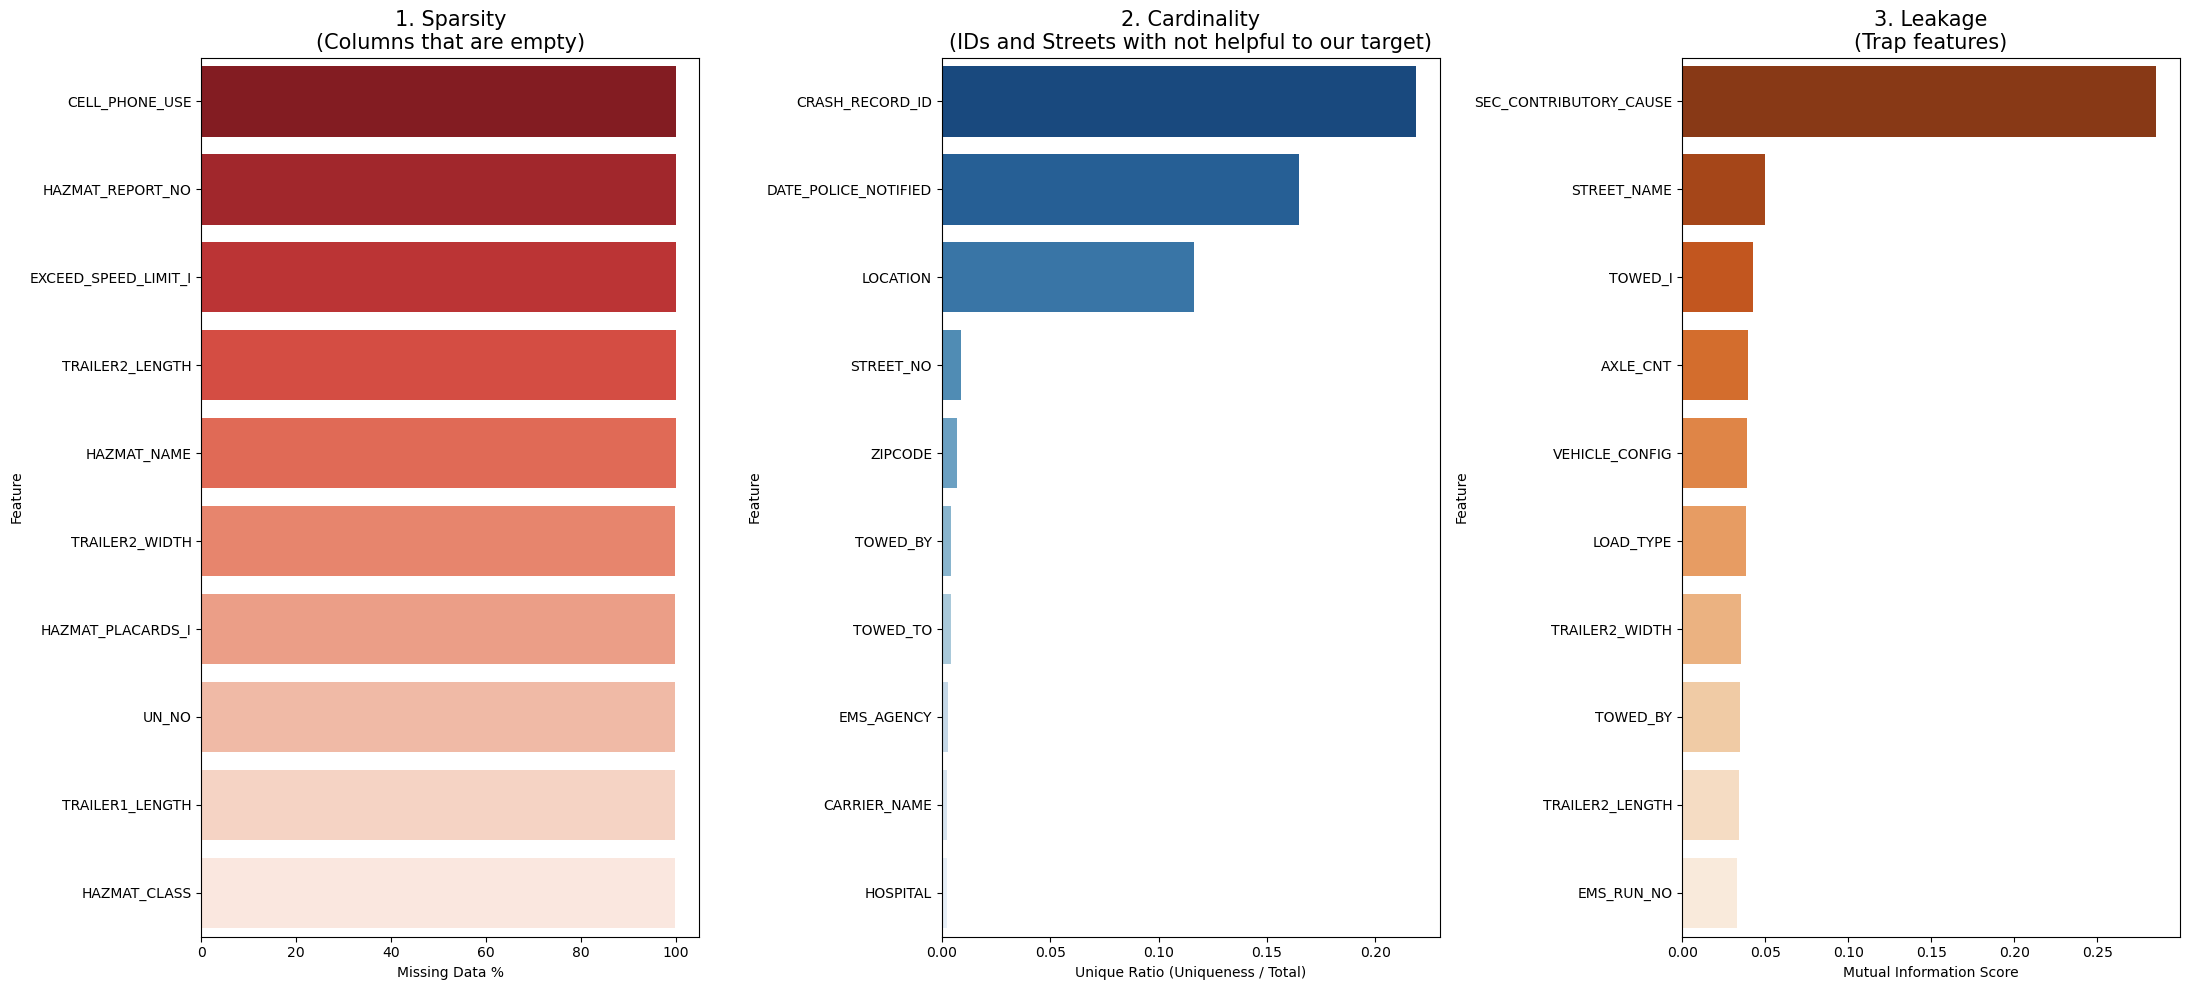

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif

# Create the Visual DataFrame (Temporary Merge)
df_audit = crashes.merge(vehicles, on='CRASH_RECORD_ID', how='left') \
                  .merge(people, on='CRASH_RECORD_ID', how='left')

# Calculation 
def get_proof_metrics(df, features, target):
    results = []
    # Sample for speed (Mutual Info can be slow)
    df_sample = df.sample(min(10000, len(df)), random_state=42)
    
    for col in features:
        if col not in df.columns: continue
        
        # Metric A: Sparsity (Missing %)
        missing = df[col].isnull().mean() * 100
        
        # Metric B: Cardinality (Unique/Total)
        cardinality = df[col].nunique() / len(df)
        
        # Metric C: Leakage (Mutual Information Score)
        # Factorize handles strings for math
        x_enc = pd.factorize(df_sample[col])[0].reshape(-1, 1)
        y_enc = pd.factorize(df_sample[target])[0]
        mi = mutual_info_classif(x_enc, y_enc)[0]
        
        results.append({'Feature': col, 'Missing_Pct': missing, 
                        'Cardinality': cardinality, 'Leakage_Score': mi})
    return pd.DataFrame(results)

# Generate the data
proof_df = get_proof_metrics(df_audit, ignore_features, 'PRIM_CONTRIBUTORY_CAUSE')

# The 3-Panel Dashboard
fig, axes = plt.subplots(1, 3, figsize=(22, 10))

# Panel 1: Sparsity (Missing Values)
top_missing = proof_df.nlargest(10, 'Missing_Pct')
sns.barplot(ax=axes[0], data=top_missing, x='Missing_Pct', y='Feature', palette='Reds_r')
axes[0].set_title("1. Sparsity\n(Columns that are empty)", fontsize=15)
axes[0].set_xlabel("Missing Data %")

# Panel 2: Cardinality (Overfitting Risk)
top_card = proof_df.nlargest(10, 'Cardinality')
sns.barplot(ax=axes[1], data=top_card, x='Cardinality', y='Feature', palette='Blues_r')
axes[1].set_title("2. Cardinality\n(IDs and Streets with not helpful to our target)", fontsize=15)
axes[1].set_xlabel("Unique Ratio (Uniqueness / Total)")

# Panel 3: Leakage (Cheating Risk)
top_leak = proof_df.nlargest(10, 'Leakage_Score')
sns.barplot(ax=axes[2], data=top_leak, x='Leakage_Score', y='Feature', palette='Oranges_r')
axes[2].set_title("3. Leakage\n(Trap features)", fontsize=15)
axes[2].set_xlabel("Mutual Information Score")

plt.tight_layout()
plt.show()

## Improved Model

### Random Forest Model
### Why Random Forest for thise problem?
This model is suitable because:
- It handles **large datasets with many features** very well
- It captures **non-linear relationship** common in crash data
- It reduces overfiting compared to asingle tree

In [66]:
X_train = X_train.select_dtypes(include=['int64', 'float64'])
X_test = X_test.select_dtypes(include=['int64', 'float64'])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Fit only on training target (IMPORTANT BEST PRACTICE)
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions
rf_pred = rf.predict(X_test)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.33360500777212954
              precision    recall  f1-score   support

           0       0.46      0.14      0.21      6175
           1       0.76      0.07      0.14      8103
           2       0.55      0.15      0.23     10796
           3       0.30      0.87      0.45     31171
           4       0.33      0.24      0.28     23617
           5       0.53      0.27      0.36      6090
           6       0.69      0.05      0.09      7859
           7       0.53      0.06      0.11     13337
           8       0.64      0.04      0.07      8779
           9       0.52      0.20      0.29      3088

    accuracy                           0.33    119015
   macro avg       0.53      0.21      0.22    119015
weighted avg       0.46      0.33      0.26    119015



### XGBoost Model
We train a more advanced boosting model to improve performance.

In [68]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 0.29886989034995587
              precision    recall  f1-score   support

           0       0.30      0.10      0.15      6175
           1       0.53      0.03      0.05      8103
           2       0.35      0.09      0.14     10796
           3       0.29      0.84      0.43     31171
           4       0.28      0.22      0.25     23617
           5       0.42      0.24      0.30      6090
           6       0.65      0.02      0.03      7859
           7       0.39      0.02      0.04     13337
           8       0.57      0.01      0.02      8779
           9       0.35      0.19      0.25      3088

    accuracy                           0.30    119015
   macro avg       0.41      0.17      0.17    119015
weighted avg       0.38      0.30      0.22    119015



### Model Comparison
We compare both models and select the best performing one.

In [69]:
rf_acc = accuracy_score(y_test, rf_pred)
xgb_acc = accuracy_score(y_test, xgb_pred)

if xgb_acc > rf_acc:
    print("✅ XGBoost performs better")
else:
    print("✅ Random Forest performs better")

✅ Random Forest performs better


### Model Evaluation Conclusion

Although Random Forest achieved slightly higher accuracy (33.36%) compared to XGBoost (29.89%), both models show poor overall predictive performance.

### Key Observations:
- Strong class imbalance in dataset
- Model is biased toward majority class (Class 3)
- Minority classes are poorly predicted
- Overall accuracy is low (~30%)

### Final Insight:
Random Forest is selected as the better model, but further improvements are required using:
- Class balancing (SMOTE or class weights)
- Advanced feature engineering
- Hyperparameter tuning

### Improve Data
Since accuracy is very low we fix the root problem first **Class imbalance**

In [74]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

### Handling Class Imbalance

Since the dataset is highly imbalanced, we apply SMOTE to generate synthetic samples for minority classes.

This helps the model:
- Learn all crash categories equally
- Reduce bias toward majority class
- Improve recall for rare crash types

### Retrain Improved Model

In [75]:
rf.fit(X_train_bal, y_train_bal)
rf_pred = rf.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, rf_pred))

Improved Accuracy: 0.245893374784691


### Hyperparameter Tuning
This is where we make the model stronger

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],      
    'max_depth': [10, 15],      
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,               
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_bal, y_train_bal)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 15, 'n_estimators': 200}


### Hyperparameter Tuning

We use GridSearchCV to find the best combination of parameters for Random Forest.

This helps:
- Improve accuracy
- Reduce overfitting
- Optimize model performance

### Feature Importance

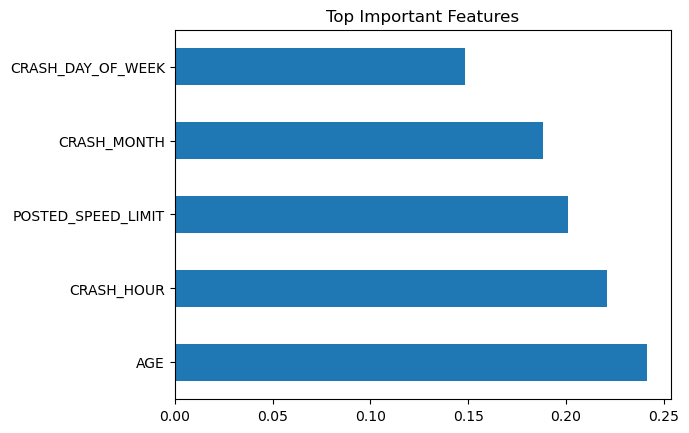

In [80]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns)
importance.nlargest(15).plot(kind='barh')
plt.title("Top Important Features")
plt.show()

### Evaluating Model Improvement using Macro F1-score

In [83]:
from sklearn.ensemble import RandomForestClassifier

rf_advanced = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train model
rf_advanced.fit(X_train, y_train)

# Generate predictions
rf_adv_pred = rf_advanced.predict(X_test)

from sklearn.metrics import f1_score

old_f1 = f1_score(y_test, rf_pred, average='macro')
new_f1 = f1_score(y_test, rf_adv_pred, average='macro')

print("Old Macro F1:", old_f1)
print("New Macro F1:", new_f1)

Old Macro F1: 0.24217918972527536
New Macro F1: 0.3344085203828027


### Model Improvement Evaluation (Before vs After Tuning)

To evaluate model performance, we compared the Macro F1-score before and after applying model improvements such as class weighting and advanced parameter settings.

### Results:
- Before Tuning Macro F1: 0.242
- After Tuning Macro F1: 0.334

### Interpretation:
The model shows a significant increase in Macro F1-score after tuning, indicating improved performance across all classes.

### Key Insight:
- The model is less biased toward the majority class after tuning
- Predictions for minority classes have improved
- Overall classification performance is more balanced

### Conclusion:
Although accuracy did not significantly increase, the model after tuning is more reliable and better suited for this imbalanced classification problem. This highlights the importance of using balanced evaluation metrics such as Macro F1-score instead of relying solely on accuracy.